In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
%matplotlib inline

config = json.load(open('config.json'))
results = np.load('data/results/vlmd_multiscan_ica-aroma-gsr_modes-6_latents-5_lambda=0.001.npz', allow_pickle=True)
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df = df[df['include_scan_coil_numvols']]
df = df[df['include_manual_qc']]
df = df[df['ratio_outliers_fd0.5_std_dvars1.5'] < config["ratio_outliers_fd0.5_std_dvars1.5"]]

In [3]:
results.files

['latents',
 'omega',
 'modes_hat',
 'alpha',
 'reg_lambda',
 'reg_rho',
 'tolerance',
 'max_iter']

In [4]:
np.sum(results['latents']==0)

np.int64(0)

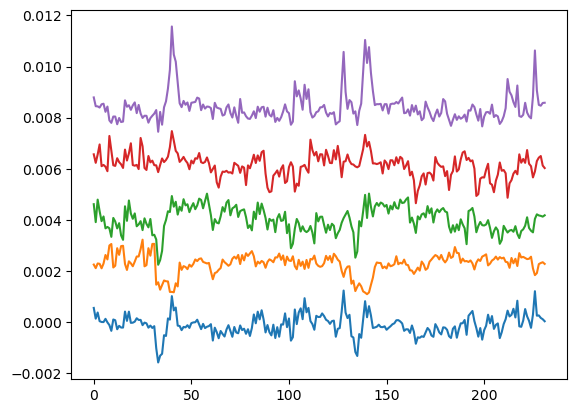

In [5]:
plt.plot(results['latents'].T+0.002*np.arange(5));

In [12]:
results['modes_hat'].shape

(134, 6, 5, 401)

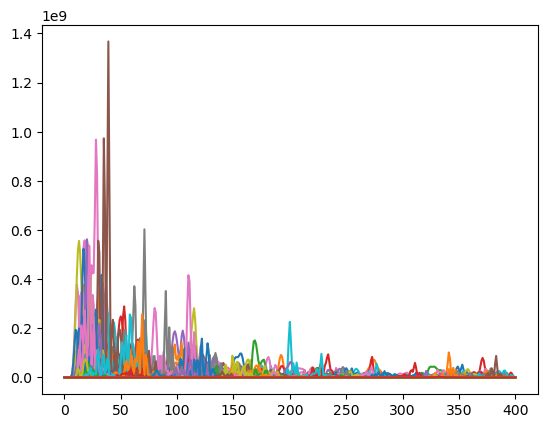

In [13]:
plt.figure()
for i in range(results['modes_hat'].shape[0]):
    plt.plot(np.abs(results['modes_hat'][i,:,1,:].T)**2);

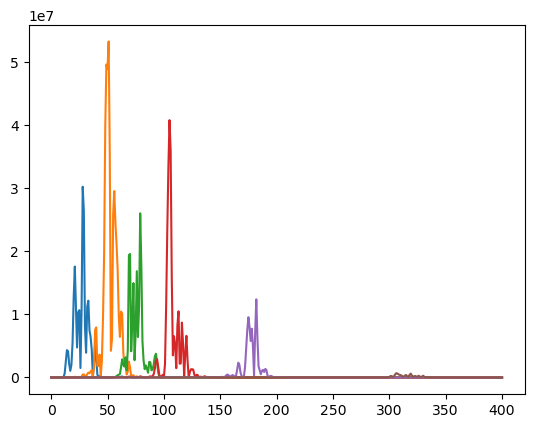

In [16]:
plt.plot(np.abs(results['modes_hat'][0,:,2,:].T)**2);

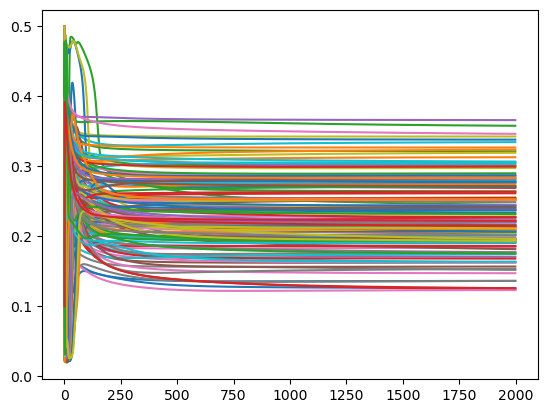

In [21]:
plt.plot(results['omega'][:,:,3]);

<Axes: xlabel='PPL_mcg/L'>

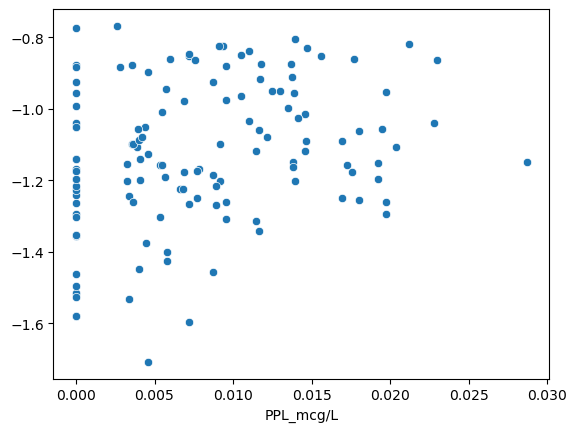

In [10]:
sns.scatterplot(y=np.log(results['omega'][-1,:,4]),x=df['PPL_mcg/L'])

In [8]:
df

,subject,session,task,run,age,sex,drug_admin_time,ppl_time,sdi_time,scan_start_time,...,coil_active,scanner,include_scan_coil_numvols,include_manual_qc,ratio_outliers_fd0.5_std_dvars1.5,scan_filename,preproc_filename_volumetric,preproc_filename_cifti,preproc_filename_cifti_despiked,preproc_filename_cifti_aroma
3,sub-53888,ses-PSI,task-rest,run-1,27.000000,Female,2019-09-01 10:15:00,2019-09-01 09:57:00,2019-09-01 09:57:00,2019-09-01 09:17:57,...,HC1-6,MR45,True,True,0.073333,data/raw/sub-53888/ses-PSI/func/sub-53888_ses-...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...
4,sub-53888,ses-PSI,task-rest,run-2,27.000000,Female,2019-09-01 10:15:00,2019-09-01 11:25:00,2019-09-01 11:25:00,2019-09-01 11:05:46,...,HC1-6,MR45,True,True,0.073333,data/raw/sub-53888/ses-PSI/func/sub-53888_ses-...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...
5,sub-53888,ses-PSI,task-rest,run-3,27.000000,Female,2019-09-01 10:15:00,2019-09-01 11:25:00,2019-09-01 11:25:00,2019-09-01 11:37:24,...,HC1-6,MR45,True,True,0.173333,data/raw/sub-53888/ses-PSI/func/sub-53888_ses-...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...
6,sub-53888,ses-PSI,task-rest,run-4,27.000000,Female,2019-09-01 10:15:00,2019-09-01 12:55:00,2019-09-01 12:55:00,2019-09-01 13:02:44,...,HC1-6,MR45,True,True,0.073333,data/raw/sub-53888/ses-PSI/func/sub-53888_ses-...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...
7,sub-53888,ses-PSI,task-rest,run-5,27.000000,Female,2019-09-01 10:15:00,2019-09-01 15:57:00,2019-09-01 15:57:00,2019-09-01 15:39:07,...,HC1-6,MR45,True,True,0.156667,data/raw/sub-53888/ses-PSI/func/sub-53888_ses-...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...,data/preprocessed/sub-53888/ses-PSI/func/sub-5...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,sub-57214,ses-PSI,task-rest,run-3,29.638356,Male,2021-04-06 10:54:00,2021-04-06 11:58:00,2021-04-06 12:23:00,2021-04-06 12:00:21,...,HEA;HEP,MR001,True,True,0.014667,data/raw/sub-57214/ses-PSI/func/sub-57214_ses-...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...
238,sub-57214,ses-PSI,task-rest,run-4,29.638356,Male,2021-04-06 10:54:00,2021-04-06 12:23:00,2021-04-06 12:23:00,2021-04-06 12:37:14,...,HEA;HEP,MR001,True,True,0.049333,data/raw/sub-57214/ses-PSI/func/sub-57214_ses-...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...
239,sub-57214,ses-PSI,task-rest,run-5,29.638356,Male,2021-04-06 10:54:00,2021-04-06 14:13:00,2021-04-06 14:13:00,2021-04-06 14:17:57,...,HEA;HEP,MR001,True,True,0.192000,data/raw/sub-57214/ses-PSI/func/sub-57214_ses-...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...,data/preprocessed/sub-57214/ses-PSI/func/sub-5...
240,sub-57214,ses-PSI,task-rest,run-6,29.638356,Male,2021-04-06 10:54:00,2021-04-06 16:57:00,2021-04-06 16:05:00,2021-04-06 16:14:27,...,HEA;HEP,MR001,True,True,0.032000,data/raw/sub-57214/ses-PSI/func/sub-57214_ses-...,data/preprocessed/sub-57214/ses-PSI